# Iris dataset

with library

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = pd.read_csv("iris (1) (1).csv")

X = iris.drop("species", axis=1)
y = iris["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k = 5
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



without library

In [5]:
import pandas as pd
import numpy as np
from collections import Counter

data = pd.read_csv("iris (1) (1).csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

def distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def knn_predict(X_train, y_train, x_test, k):
    distances = []

    for i in range(len(X_train)):
        d = distance(x_test, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = [distances[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

k = 5

predictions = []
for x in X_test:
    predictions.append(knn_predict(X_train, y_train, x, k))

correct = 0
for i in range(len(y_test)):
    if predictions[i] == y_test[i]:
        correct += 1

accuracy = correct / len(y_test)

print("Accuracy:", accuracy)

Accuracy: 0.8


In [6]:
labels = list(set(y))

matrix = [[0 for _ in labels] for _ in labels]

for i in range(len(y_test)):
    actual = labels.index(y_test[i])
    predicted = labels.index(predictions[i])
    matrix[actual][predicted] += 1

print("Confusion Matrix:")
for row in matrix:
    print(row)

Confusion Matrix:
[24, 6, 0]
[0, 0, 0]
[0, 0, 0]


In [7]:
for i, label in enumerate(labels):

    tp = matrix[i][i]
    fp = sum(row[i] for row in matrix) - tp
    fn = sum(matrix[i]) - tp

    precision = tp / (tp + fp) if (tp+fp) != 0 else 0
    recall = tp / (tp + fn) if (tp+fn) != 0 else 0

    print("\nClass:", label)
    print("Precision:", precision)
    print("Recall:", recall)


Class: virginica
Precision: 1.0
Recall: 0.8

Class: versicolor
Precision: 0.0
Recall: 0

Class: setosa
Precision: 0
Recall: 0


# Diabetes dataset

with library

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

diabetes = pd.read_csv("diabetes.csv")

X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

k = 5
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.6948051948051948

Confusion Matrix:
[[79 20]
 [27 28]]


without library

In [8]:
import pandas as pd
import numpy as np
from collections import Counter

data = pd.read_csv("diabetes.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Feature Scaling
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X = (X - mean) / std

In [9]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [10]:
def distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [11]:
def knn_predict(X_train, y_train, x_test, k):

    distances = []

    for i in range(len(X_train)):
        d = distance(x_test, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = [distances[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

In [12]:
k = 5
predictions = []

for x in X_test:
    predictions.append(knn_predict(X_train, y_train, x, k))

correct = 0
for i in range(len(y_test)):
    if predictions[i] == y_test[i]:
        correct += 1

accuracy = correct / len(y_test)

print("Accuracy:", accuracy)

Accuracy: 0.7207792207792207


# Heart database

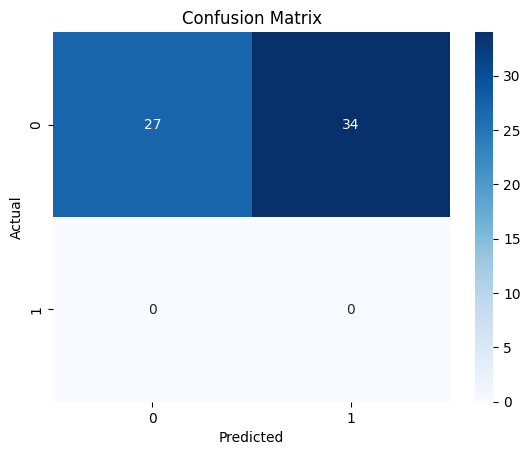

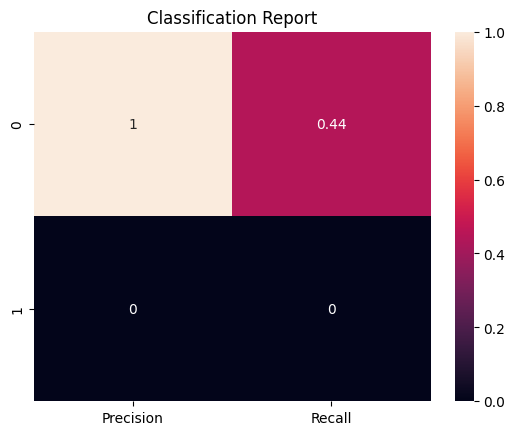

Best K: 4
Accuracy: 0.4426229508196721


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

data = pd.read_csv("heart.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

def distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def knn_predict(X_train, y_train, x_test, k):
    distances = []
    for i in range(len(X_train)):
        d = distance(x_test, X_train[i])
        distances.append((d, y_train[i]))
    distances.sort(key=lambda x: x[0])
    neighbors = [distances[i][1] for i in range(k)]
    return Counter(neighbors).most_common(1)[0][0]

best_k = 1
best_score = 0

for k in range(1, 21):
    predictions = []
    for x in X_test:
        predictions.append(knn_predict(X_train, y_train, x, k))
    correct = sum(predictions[i] == y_test[i] for i in range(len(y_test)))
    score = correct / len(y_test)
    if score > best_score:
        best_score = score
        best_k = k

predictions = []
for x in X_test:
    predictions.append(knn_predict(X_train, y_train, x, best_k))

labels = list(set(y))

cm = [[0 for _ in labels] for _ in labels]

for i in range(len(y_test)):
    actual = labels.index(y_test[i])
    predicted = labels.index(predictions[i])
    cm[actual][predicted] += 1

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

report = []

for i, label in enumerate(labels):
    tp = cm[i][i]
    fp = sum(row[i] for row in cm) - tp
    fn = sum(cm[i]) - tp
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    report.append([precision, recall])

report = np.array(report)

sns.heatmap(report, annot=True, xticklabels=["Precision","Recall"], yticklabels=labels)
plt.title("Classification Report")
plt.show()

print("Best K:", best_k)
print("Accuracy:", best_score)